### 비지도 학습
* 비지도 학습은 데이터에 대한 레이블 없이 입력 데이터의 패턴이나 구조를 학습하는 방법이다.
* 데이터에 대한 정답(레이블)이 없기 때문에 학습 과정에서 지도 학습처럼 입력-출력 관계를 학습하지 않고, 데이터를 스스로 그룹화하거나 내재된 특성을 찾아내는 데 초점이 맞춰진다.

# 🛒 쇼핑몰 고객 세분화 (Customer Segmentation)
### : K-Means를 활용한 '숨겨진 고객 그룹' 찾기

**목표:**
쇼핑몰 고객 데이터를 분석하여 비슷한 소비 성향을 가진 고객끼리 그룹(Cluster)으로 묶어봅니다.
이를 통해 마케팅에 활용할 수 있는 **타겟 고객층**을 정의해 봅니다.

**사용 데이터:**
* `Mall_Customers.csv`: 고객 ID, 성별, 나이, 연간 수입, 소비 점수 데이터

## 1. 도구 준비 및 데이터 불러오기
분석에 필요한 라이브러리(도구)를 가져오고, 데이터를 읽어옵니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape # 데이터 크기와 변수 확인

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# 결측치 확인
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
# 이상값 확인
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2. 데이터 전처리
K-Means는 거리 기반 알고리즘이기 때문에 데이터의 **단위(Scale)**가 매우 중요합니다.
(예: 수입은 10,000단위인데 점수는 100단위라면 거리가 왜곡됨)

따라서 모든 데이터를 평균 0, 분산 1로 맞춰주는 **표준화(StandardScaler)** 작업을 진행합니다.
여기서는 시각화를 위해 **연간 수입(Annual Income)**과 **소비 점수(Spending Score)** 두 가지만 사용합니다.

In [8]:
# 필요한 컬럼만 선택 (수입, 소비점수)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 데이터 스케일링 (거리 기반 알고리즘 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled.shape

(200, 2)

In [10]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

# KMEANS

In [11]:
from sklearn.cluster import KMeans

In [24]:
# K-Means 실행
# 직접 k의 값을 설정해보면서 그래프를 확인해보세요
kmeans = KMeans(n_clusters = 5, random_state = 42, n_init = 10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmeans_cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


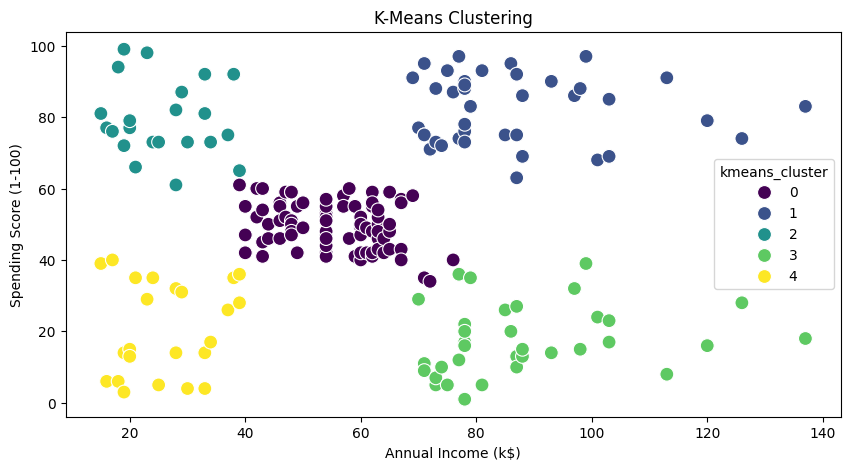

In [25]:
# 결과 시각화
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='kmeans_cluster', data=df, palette='viridis', s=100)
plt.title('K-Means Clustering')
plt.show()

## 3. 최적의 K 찾기 (Elbow Method & Silhouette Score)
몇 개의 그룹으로 나누는 게 가장 좋을까요? 수학적인 지표 두 가지를 참고하여 결정합니다.

**1. 엘보우 기법 (Elbow Method)**
* **이너셔 (Inertia):** 데이터들이 중심에 얼마나 빽빽하게 모여있는지 나타내는 값입니다. (작을수록 좋음)
* 그래프가 팔꿈치처럼 **툭 꺾이는 지점**이 최적의 K 후보입니다.

**2. 실루엣 계수 (Silhouette Score)**
* 군집화가 얼마나 잘 됐는지 보여주는 점수표입니다. (**-1 ~ 1 사이의 값**)
* **1에 가까울수록** "자기들끼리는 똘똘 뭉치고, 다른 그룹과는 확실히 멀어졌다"는 뜻으로 아주 좋은 상태입니다.
* 반면 0에 가깝거나 음수라면 군집들이 서로 겹쳐 있다는 뜻입니다.

👉 **결론:** 엘보우 그래프가 꺾이면서(Inertia 감소), 실루엣 점수도 비교적 높은 K를 선택하는 것이 좋습니다.

In [26]:
# 사이킷런 라이브러리에서 실루엣 스코어 계산 함수를 불러오기
from sklearn.metrics import silhouette_score

# 이너셔 값과 실루엣 스코어를 저장할 빈 리스트 생성 (실루엣 스코어는 엘보우 메소드 이후 뒤에서 설명 예정입니다.)
inertia = []
silhouette_scores = []

# 군집 개수(K)를 2개부터 10개까지 바꾸어가며 테스트하겠다는 의미
# 왜 1이 아니라 2부터 시작할까요? 혼자서는 '군집'이나 '이웃'을 비교할 수 없으므로 실루엣 스코어는 최소 K=2부터 계산이 가능하기 때문입니다.
k_range = range(2, 11)

for k in k_range:
    # kmeans 모델 정의
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # 표준화 전처리가 완료된 데이터(X_scaled)를 K-Means 모델에 집어넣어 학습(fit)을 시키는 동시에,
    # 각 데이터가 몇 번 그룹에 속하는지 정답 레이블(predict)을 뽑아내어 labels 변수에 담습니다.
    labels = kmeans.fit_predict(X_scaled)

    # 이너셔 값 리스트에 추가
    inertia.append(kmeans.inertia_)

    # 변환된 데이터(X_scaled)와 모델이 예측한 정답지(labels)를 silhouette_score 함수에 넘겨주어 현재 K값의 실루엣 점수를 계산합니다.
    # 그리고 그 결과 점수를 silhouette_scores 리스트에 저장합니다.
    silhouette_scores.append(silhouette_score(X_scaled, labels))

In [27]:
# 이너셔 값 확인
for k in range(len(inertia)):
    # k의 범위를 2~10으로 지정했기 때문에 k+2를 출력
    print(f'k = {k+2}, inertia = {inertia[k]:.4f}')

k = 2, inertia = 269.6910
k = 3, inertia = 157.7040
k = 4, inertia = 108.9213
k = 5, inertia = 65.5684
k = 6, inertia = 55.0573
k = 7, inertia = 44.8648
k = 8, inertia = 37.2282
k = 9, inertia = 32.3923
k = 10, inertia = 29.9819


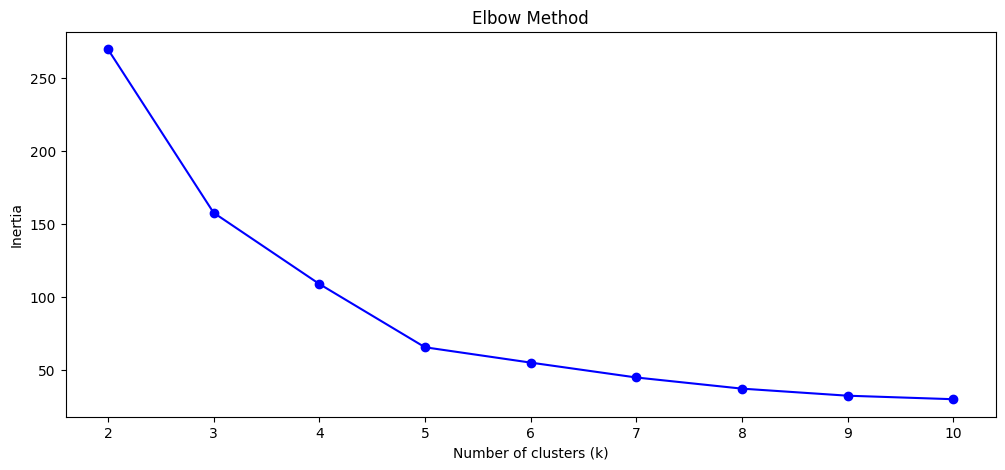

In [28]:
# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(12, 5))

# 엘보우 메소드
ax1.plot(k_range, inertia, marker='o', color='b', label='Inertia')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

plt.show()

In [29]:
# 실루엣 스코어 확인
for k in range(len(silhouette_scores)):
    print(f'k = {k+2}, silhouette_scores = {silhouette_scores[k]:.4f}')

k = 2, silhouette_scores = 0.3213
k = 3, silhouette_scores = 0.4666
k = 4, silhouette_scores = 0.4939
k = 5, silhouette_scores = 0.5547
k = 6, silhouette_scores = 0.5399
k = 7, silhouette_scores = 0.5281
k = 8, silhouette_scores = 0.4552
k = 9, silhouette_scores = 0.4571
k = 10, silhouette_scores = 0.4432


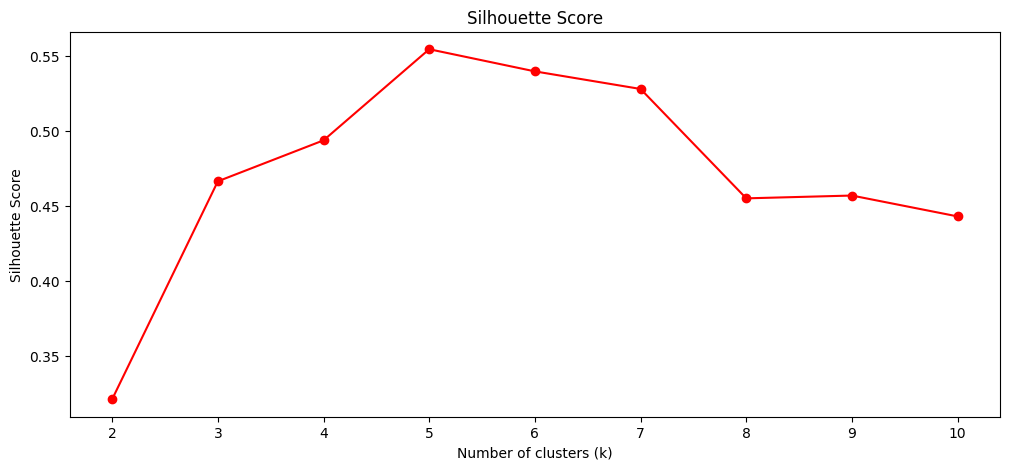

In [30]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# 실루엣 점수
ax1.plot(k_range, silhouette_scores, marker='o', color='r', label='Silhouette Score')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score')

plt.show()

## 4. K-Means 모델 학습 (K=5)
엘보우 기법과 실루엣 점수를 통해 적절한 K값을 **5개**로 결정했다고 가정하고 모델을 학습시킵니다.
컴퓨터가 스스로 데이터의 패턴을 파악하여 0~4번까지 그룹 번호를 매겨줍니다.

In [31]:
# K-Means 실행
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmeans_cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 5. 결과 시각화
나누어진 5개의 그룹을 산점도로 확인해 봅니다.
비슷한 위치(수입, 소비점수)에 있는 데이터끼리 같은 색으로 묶였는지 확인해보세요.

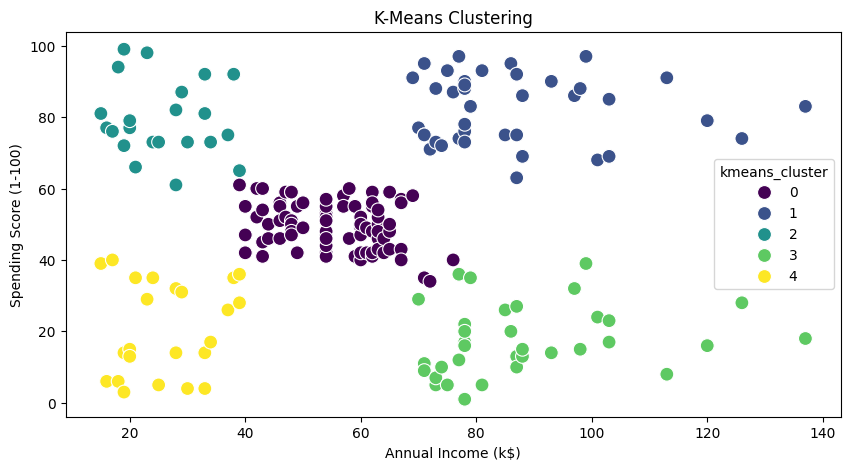

In [32]:
# 결과 시각화
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='kmeans_cluster', data=df, palette='viridis', s=100)
plt.title('K-Means Clustering')
plt.show()

## 📊 결과 해석 (Business Insight)
그래프를 보고 각 그룹의 특징을 정의해 봅시다.

1. **Cluster 0:** 중간층 (일반 고객)
2. **Cluster 1:** 고소득 고소비 (VIP 고객)
3. **Cluster 2:** 저소득 고소비 (충성 고객)
4. **Cluster 3:** 고소득 저소비 (잠재 고객)
5. **Cluster 4:** 저소득 저소비 (가격 민감 고객)


👉 결론적으로 고소득 저소비 군집에 해당되는 잠재 고객들이 **핵심 타겟 고객**으로 볼 수 있겠네요.